# 1. Discovering Meaningful Co-Reading Patterns in Comics & Graphic Novels

## Overview

In this project, we analyze the **Goodreads Comics and Graphic Novels review dataset** to uncover patterns in how users read books together. The dataset is large-scale, containing hundreds of thousands of user–book interactions, making it suitable for real-world data mining analysis.

The primary goal is to identify **co-reading patterns**, meaning which books are frequently read together by users. To achieve this, we apply **Association Rule Mining**, specifically the FP-Growth algorithm, to discover meaningful relationships between books.

A key challenge in this dataset is its **extreme sparsity and popularity imbalance**, where most book pairs never co-occur and a few books dominate interactions. This makes it necessary to carefully analyze support thresholds and use robust metrics such as **lift** to extract meaningful associations.

Overall, this project focuses on understanding **user reading behavior** and demonstrating how data mining techniques can provide insights useful for recommendation systems.

# 2. Motivation

Modern reading platforms such as Goodreads contain an overwhelming number of books across different genres. Readers often struggle to decide what to read next due to the vast number of choices and diverse personal preferences.

Traditional recommendation approaches, such as popularity-based suggestions or average ratings, often fail to capture **deeper behavioral patterns**. For example, highly rated or popular books may dominate recommendations, even if they are not strongly related to a user's actual reading interests.

To address this limitation, we analyze **co-reading behavior**, which focuses on understanding which books tend to appear together in users’ reading histories. This provides a more natural representation of user preferences compared to isolated ratings.

Association Rule Mining is particularly well-suited for this task because it can uncover relationships of the form:

> “If a user reads Book A, they are likely to also read Book B.”

Such insights can be directly useful for:
- improving book recommendation systems  
- understanding reader communities  
- identifying hidden relationships between books  

By focusing on co-reading patterns rather than single-item popularity, this project aims to move closer to **behavior-driven recommendations**.

# 3. Dataset Overview

This project uses the **Goodreads Reviews — Comics & Graphic Novels dataset**, a subset of the larger Goodreads Book Graph dataset collected for research purposes.  
Here is the dataset source:  
https://cseweb.ucsd.edu/~jmcauley/datasets/goodreads.html  

The dataset consists of **user-generated reviews and interaction data** between users and books. It combines structured features such as user–item relationships with unstructured textual reviews. However, this analysis focuses primarily on **interaction behavior** to study co-reading patterns.

---

### Key Statistics

- **Total Reviews:** ~542,338  
- **Unique Users:** ~59,347  
- **Unique Books:** ~89,311  
- **Data Type:** User–book interaction data (transactional)

Each record corresponds to a **single review written by a user for a book**, forming a natural mapping between users and the items (books) they have interacted with.

---

### Data Characteristics

The dataset exhibits properties typical of large-scale interaction data:

- It can be represented as a **transactional dataset**, where each user corresponds to a *basket* of books they have reviewed.
- It captures **real-world reading behavior at scale**, making it suitable for data mining tasks such as frequent pattern discovery.
- The dataset includes both structured and unstructured attributes:

  - `user_id` – unique user identifier  
  - `book_id` – unique book identifier  
  - `review_id` – unique review identifier  
  - `rating` – integer rating from 1 to 5  
  - `review_text` – user-generated textual review  
  - `date_added`, `date_updated` – timestamps  
  - `read_at`, `started_at` – reading timestamps (often missing)  
  - `n_votes`, `n_comments` – engagement signals  
  - `review_len_tokens` – derived feature representing review length  

Although textual information is available, this project focuses on **user–item interactions**, as they naturally support co-occurrence and association-based analysis.

---

### Important Observations

From an initial analysis of the dataset, several key characteristics influence the modeling approach:

- The dataset is **large but highly sparse**, meaning most users interact with only a small subset of books.
- There is a strong **popularity imbalance**, where a small number of books dominate interactions.
- The structure naturally supports **market-basket style analysis**, where each user can be treated as a transaction containing multiple books.

These properties directly motivate the use of **frequent pattern mining techniques** and impact decisions such as threshold selection and evaluation metrics.


# 4. Research Question

The primary research question addressed in this project is:

### RQ1:
**What frequent co-occurring book sets emerge under varying support thresholds, and how can support, confidence, and lift be used to identify meaningful associations?**

### Explanation

This question focuses on understanding:

- **Which books are commonly read together?**
- **How do different support thresholds affect the number and quality of discovered patterns?**
- **How can we distinguish meaningful relationships from trivial popularity-based patterns?**

To answer this, we use **Association Rule Mining**, which discovers relationships in the form:

> X → Y  
> (If X appears, Y is likely to appear)

These rules are evaluated using three key metrics:

- **Support:** Measures how frequently a set of books appears together in the dataset. [2](https://www.geeksforgeeks.org/machine-learning/association-rule/)  
- **Confidence:** Measures how often the rule is correct when the antecedent occurs. [2](https://www.geeksforgeeks.org/machine-learning/association-rule/)  
- **Lift:** Measures the strength of association compared to random chance; a value greater than 1 indicates a meaningful relationship. [2](https://www.geeksforgeeks.org/machine-learning/association-rule/)  

By analyzing these metrics across different thresholds, we aim to identify **strong, non-trivial co-reading patterns**.

In [1]:

# # 1. Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# # 2. Set your project path
# PROJECT_PATH = "/content/drive/MyDrive/Goodreads_Reviews"

import sys
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
PROJECT_PATH = "."
sys.path.append(f"{PROJECT_PATH}/src")


# 1. DataLoading

In [2]:
from data_loader import load_goodreads_data, dataset_summary

# Load data
df = load_goodreads_data(f"{PROJECT_PATH}/data/raw/goodreads_reviews_comics_graphic.json.gz")

print("\nSample data:")
display(df.head(5))

# Show summary
dataset_summary(df)

Loading dataset...
Data loaded successfully.


Sample data:


,user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
0,dc3763cdb9b2cae805882878eebb6a32,18471619,66b2ba840f9bd36d6d27f46136fe4772,3,Sherlock Holmes and the Vampires of London \n ...,Thu Dec 05 10:44:25 -0800 2013,Thu Dec 05 10:45:15 -0800 2013,Tue Nov 05 00:00:00 -0800 2013,,0,0
1,bafc2d50014200cda7cb2b6acd60cd73,6315584,72f1229aba5a88f9e72f0dcdc007dd22,4,"I've never really liked Spider-Man. I am, howe...",Wed Aug 10 06:06:48 -0700 2016,Fri Aug 12 08:49:54 -0700 2016,Fri Aug 12 08:49:54 -0700 2016,Wed Aug 10 00:00:00 -0700 2016,0,0
2,bafc2d50014200cda7cb2b6acd60cd73,29847729,a75309355f8662caaa5e2c92ab693d3f,4,"A very quick introduction, this is coming out ...",Thu Apr 21 07:44:00 -0700 2016,Thu Apr 21 07:59:28 -0700 2016,Thu Apr 21 07:59:28 -0700 2016,Thu Apr 21 00:00:00 -0700 2016,0,0
3,bafc2d50014200cda7cb2b6acd60cd73,18454118,c3cc5a3e1d6b6c9cf1c044f306c8e752,5,I've been waiting so long for this. I first st...,Mon Mar 03 17:45:56 -0800 2014,Mon Mar 03 17:54:11 -0800 2014,Sat Mar 01 00:00:00 -0800 2014,Sat Mar 01 00:00:00 -0800 2014,1,0
4,bafc2d50014200cda7cb2b6acd60cd73,2239435,cc444be37ab0a42bfb4dd818cb5edd10,4,The only thing more entertaining than this boo...,Wed Apr 03 12:37:48 -0700 2013,Wed Apr 03 13:03:36 -0700 2013,Wed Apr 03 13:03:36 -0700 2013,,0,0


========== DATASET SUMMARY ==========

Total rows (reviews): 542,338
Total columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 542338 entries, 0 to 542337
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       542338 non-null  str  
 1   book_id       542338 non-null  str  
 2   review_id     542338 non-null  str  
 3   rating        542338 non-null  int64
 4   review_text   542338 non-null  str  
 5   date_added    542338 non-null  str  
 6   date_updated  542338 non-null  str  
 7   read_at       542338 non-null  str  
 8   started_at    542338 non-null  str  
 9   n_votes       542338 non-null  int64
 10  n_comments    542338 non-null  int64
dtypes: int64(3), str(8)
memory usage: 45.5 MB
None

Unique counts:
- Unique users: 59,347
- Unique books: 89,311



## 📊 Dataset Overview

### 📁 Dataset Used
We used the Goodreads dataset:

**File:** `goodreads_reviews_comics_graphic.json.gz`  
This dataset contains user reviews for books in the *Comics & Graphic Novels* category.

---

### 📦 Dataset Statistics

- **Total Reviews:** 542,338  
- **Total Features (Columns):** 11  
- **Memory Usage:** ~45.5 MB  

---

### 👥 Entity Counts

- **Unique Users:** 59,347  
- **Unique Books:** 89,311  

---

### 🧾 Data Schema

The dataset contains the following key features:

| Column Name     | Description |
|----------------|------------|
| `user_id`      | Unique identifier for each user |
| `book_id`      | Unique identifier for each book |
| `review_id`    | Unique identifier for each review |
| `rating`       | User rating (numeric) |
| `review_text`  | Text of the user review |
| `date_added`   | Date review was added |
| `date_updated` | Date review was updated |
| `read_at`      | Date when the book was read |
| `started_at`   | Date when reading started |
| `n_votes`      | Number of votes received |
| `n_comments`   | Number of comments |

---

### 🔍 Key Observations

- The dataset is **large-scale**, with over 500K reviews, making it suitable for data mining tasks.  
- **High sparsity**: While there are ~59K users and ~89K books, each user interacts with only a small subset.  
- The data includes both:
  - ✅ **Structured features** (ratings, IDs)  
  - ✅ **Unstructured text** (`review_text`)  
- This enables multiple analyses such as:
  - Frequent itemset mining (co-reading patterns)  
  - Association rule mining  
  - Text-based clustering or TF-IDF analysis  

---

### ✅ Relevance to Project

This dataset is ideal for:

- Identifying **co-occurring book reading patterns**
- Understanding **user behavior**
- Building **recommendation systems** using:
  - FP-Growth
  - Association Rules  

---

# 2. Preprocessing


In [70]:
#Run preprocessing pipeline

from preprocessing import preprocess_pipeline

df_processed, baskets = preprocess_pipeline(df, base_path=PROJECT_PATH)

print("\nSample baskets:")
display(baskets.head())

print(f"\nTotal baskets: {len(baskets)}")


Handling missing values and converting data types...
Missing values and data types handled.
Cleaning core identifier columns...
Removed 12,806 rows due to missing identifiers or invalid ratings.
Preparing review text columns...
Text cleaned and review_len_tokens created.
Duplicate rows detected: 0
Creating user baskets...
Total users before filtering: 58,111
Filtering baskets with fewer than 2 books...
Removed 25,438 users.
Remaining users: 32,673
Saved outputs:
 - /content/drive/MyDrive/Goodreads_Reviews/data/processed/cleaned_data.csv
 - /content/drive/MyDrive/Goodreads_Reviews/data/processed/baskets.pkl
Preprocessing complete.

Sample baskets:


,book_id
user_id,
0005a08accd53b1e19c52109a1f478cb,"[107037, 119162, 1472402, 3285607]"
0006260f85929db85eddee3a0bd0e504,"[17260261, 18759090, 24069836, 24685138, 24691..."
000700ecd5db3a9b0c4e392ed2e4f70b,"[11790194, 13271416]"
0008931c0cde961e9c802c5a58196d23,"[13571757, 17703205, 17703212, 22855252, 22855..."
000a9539c044b397780166167b1327b3,"[1142008, 16002165, 23017945, 23732096, 297755..."



Total baskets: 32673


## ⚙️ Preprocessing Summary

### 📁 Input File
- `goodreads_reviews_comics_graphic.json.gz` (raw reviews dataset)

---

### 🧹 Key Preprocessing Steps

- Handled missing values and fixed data types  
- Removed **12,806 invalid rows** (missing IDs or ratings)  
- Cleaned review text and created text features  
- Removed duplicate rows (0 duplicates found)  

---

### 🧺 Basket Creation

- Initial users: **58,111**  
- Removed users with < 2 books: **25,438**  
- Final users (baskets): **32,673**  

---

### 💾 Output Files

- `data/processed/cleaned_data.csv`  
- `data/processed/baskets.pkl`  

---

### ✅ Result

- Created **32,673 valid user baskets** for frequent itemset mining  
- Data is now clean, structured, and ready for FP-Growth  

---

# Frequent Itemset Mining with different support thresholds

In [6]:
import sys

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sys.path.append(f"{PROJECT_PATH}/src")

from itemset_mining import run_pipeline

results = run_pipeline(
    base_path=PROJECT_PATH,
    support=0.005,
    min_user_freq=5,
    max_len=4,
    min_lift=1.0
)

results["summary"]

Running pipeline for support = 0.005
Loading baskets...
Loaded baskets for 32,673 users.
Filtering books with user frequency < 5...
Books kept after filtering: 18,074
Users remaining after filtering: 29,261
Creating transaction matrix...
Transaction matrix shape: (29261, 18074)
Running FP-Growth with min_support=0.005, max_len=4...
Frequent itemsets found: 779
Generating rules with min_lift=1.0...
Rules generated: 2,126
Saved: /content/drive/MyDrive/Goodreads_Reviews/outputs/itemsets/itemsets_sup_0005.csv
Saved: /content/drive/MyDrive/Goodreads_Reviews/outputs/itemsets/rules_sup_0005.csv

Itemset mining complete for support = 0.005.


{'support': 0.005,
 'min_user_freq': 5,
 'max_len': 4,
 'num_itemsets': 779,
 'num_rules': 2126}

In [8]:
# Generate plots for support 0.005
from plots import plot_rq1_results

results = plot_rq1_results(
    base_path=PROJECT_PATH,
    support=0.005,
    min_user_freq = 5,
    max_len=4
)

Generating plots for support=0.005, min_user_freq=5, max_len=4
Plots saved to: /content/drive/MyDrive/Goodreads_Reviews/outputs/figures/sup_0005_freq_5_len_4


## 📈 Frequent Itemset Mining (Support = 0.005)

### ⚙️ Configuration
- Minimum Support: 0.005  
- Minimum User Frequency: 5  
- Maximum Itemset Length: 4  
- Minimum Lift: 1.0  

---

### 📊 Results

- **Total Users (after filtering):** 29,261  
- **Books Retained:** 18,074  
- **Frequent Itemsets:** 779  
- **Association Rules:** 2,126  

---

### ✅ Summary

- Lower support (0.005) produced **more itemsets and rules**  
- Helps capture **broader co-reading patterns**  
- Suitable for improving **recommendation coverage**  
- All plots were successfully generated and saved in the `outputs/figures/` directory.
---

In [9]:
results = run_pipeline(
    base_path=PROJECT_PATH,
    support=0.01,
    min_user_freq=5,
    max_len=4,
    min_lift=1.0
)

results["summary"]

Running pipeline for support = 0.01
Loading baskets...
Loaded baskets for 32,673 users.
Filtering books with user frequency < 5...
Books kept after filtering: 18,074
Users remaining after filtering: 29,261
Creating transaction matrix...
Transaction matrix shape: (29261, 18074)
Running FP-Growth with min_support=0.01, max_len=4...
Frequent itemsets found: 180
Generating rules with min_lift=1.0...
Rules generated: 350
Saved: /content/drive/MyDrive/Goodreads_Reviews/outputs/itemsets/itemsets_sup_001.csv
Saved: /content/drive/MyDrive/Goodreads_Reviews/outputs/itemsets/rules_sup_001.csv

Itemset mining complete for support = 0.01.


{'support': 0.01,
 'min_user_freq': 5,
 'max_len': 4,
 'num_itemsets': 180,
 'num_rules': 350}

In [10]:
# Generate plots for support 0.01
from plots import plot_rq1_results

results = plot_rq1_results(
    base_path=PROJECT_PATH,
    support=0.01,
    min_user_freq=5,
    max_len=4
)

Generating plots for support=0.01, min_user_freq=5, max_len=4
Plots saved to: /content/drive/MyDrive/Goodreads_Reviews/outputs/figures/sup_001_freq_5_len_4


## 📈 Frequent Itemset Mining (Support = 0.01)

### ⚙️ Configuration
- Minimum Support: 0.01  
- Minimum User Frequency: 5  
- Maximum Itemset Length: 4  
- Minimum Lift: 1.0  

---

### 📊 Results

- **Total Users (after filtering):** 29,261  
- **Books Retained:** 18,074  
- **Frequent Itemsets:** 180  
- **Association Rules:** 350  

---

### ✅ Summary

- Moderate support (0.01) produced **fewer but stronger patterns**  
- Focuses on **more common and reliable co-reading behavior**  
- Provides a good balance between **coverage and rule quality**  
- All plots were successfully generated and saved in the `outputs/figures/` directory.
---

In [11]:
results = run_pipeline(
    base_path=PROJECT_PATH,
    support=0.02,
    min_user_freq=5,
    max_len=4,
    min_lift=1.0
)

results["summary"]

Running pipeline for support = 0.02
Loading baskets...
Loaded baskets for 32,673 users.
Filtering books with user frequency < 5...
Books kept after filtering: 18,074
Users remaining after filtering: 29,261
Creating transaction matrix...
Transaction matrix shape: (29261, 18074)
Running FP-Growth with min_support=0.02, max_len=4...
Frequent itemsets found: 52
Generating rules with min_lift=1.0...
Rules generated: 32
Saved: /content/drive/MyDrive/Goodreads_Reviews/outputs/itemsets/itemsets_sup_002.csv
Saved: /content/drive/MyDrive/Goodreads_Reviews/outputs/itemsets/rules_sup_002.csv

Itemset mining complete for support = 0.02.


{'support': 0.02,
 'min_user_freq': 5,
 'max_len': 4,
 'num_itemsets': 52,
 'num_rules': 32}

In [12]:
# Generate plots for support 0.02
from plots import plot_rq1_results

results = plot_rq1_results(
    base_path=PROJECT_PATH,
    support=0.02,
    min_user_freq=5,
    max_len=4
)

Generating plots for support=0.02, min_user_freq=5, max_len=4
Plots saved to: /content/drive/MyDrive/Goodreads_Reviews/outputs/figures/sup_002_freq_5_len_4


## 📈 Frequent Itemset Mining (Support = 0.02)

### ⚙️ Configuration
- Minimum Support: 0.02  
- Minimum User Frequency: 5  
- Maximum Itemset Length: 4  
- Minimum Lift: 1.0  

---

### 📊 Results

- **Total Users (after filtering):** 29,261  
- **Books Retained:** 18,074  
- **Frequent Itemsets:** 52  
- **Association Rules:** 32  

---

### ✅ Summary

- Higher support (0.02) produced **very few but strong patterns**  
- Focuses only on **highly frequent co-reading behavior**  
- May miss less common but meaningful relationships  
- All plots were successfully generated and saved in the `outputs/figures/` directory.
---

Generating summary plots for supports: [0.005, 0.01, 0.02]


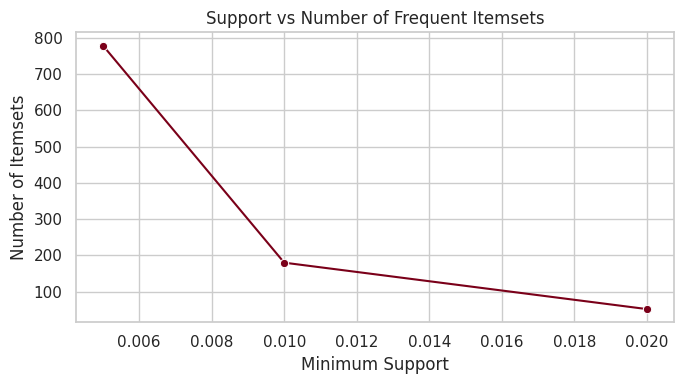

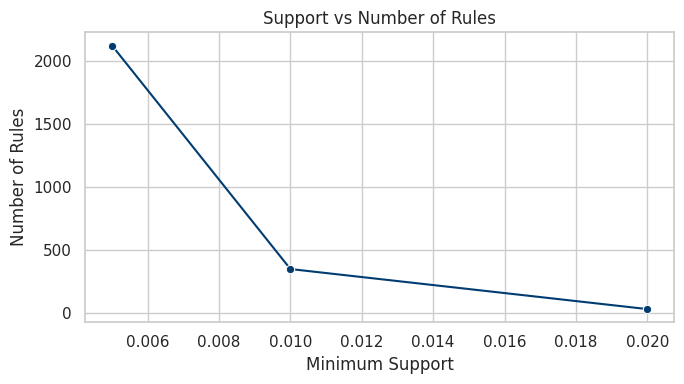

Saved summary plots at: /content/drive/MyDrive/Goodreads_Reviews/outputs/figures/summary


,support,num_itemsets,num_rules
0,0.005,779,2126
1,0.010,180,350
2,0.020,52,32


In [17]:
from summary_plots import run_summary_plots

summary_df = run_summary_plots(
    base_path=PROJECT_PATH,
    supports=[0.005, 0.01, 0.02]
)

summary_df

## 🎛️ User-Driven Frequent Itemset Mining (Adjust Support, Frequency, and Length)

In [3]:
from itemset_mining import run_pipeline
from plots import plot_rq1_results


support = float(input("Enter support (e.g., 0.005, 0.01, 0.02): "))
min_user_freq = int(input("Enter minimum user frequency (e.g., 5): "))
max_len = int(input("Enter maximum itemset length (e.g., 4): "))

print("\nRunning pipeline...\n")

#  Run pipeline
results = run_pipeline(
    base_path=PROJECT_PATH,
    support=support,
    min_user_freq=min_user_freq,
    max_len=max_len,
    min_lift=1.0
)

results = plot_rq1_results(
    base_path=PROJECT_PATH,
    support=support,
    min_user_freq=min_user_freq,
    max_len=max_len
)

ModuleNotFoundError: No module named 'mlxtend'

# Book Recommendation System based on generated rules

## 🎨✨ Now it's time to get some Comics & Graphic Novel recommendations!

Follow the steps below to explore personalized recommendations:

### 🔹 Step 1: Enter a Book ID
- select a **book ID** from the suggested list.
- Enter the chosen book ID.
- The system will display the **corresponding book title**.

---

### 🔹 Step 2: Copy the Book Title
- Copy the **exact book title** from the output.
  - Example:
    ```
    Book title: Ms. Marvel, Vol. 3: Crushed
    ```

---

### 🔹 Step 3: Generate Recommendations
- Move to the recommender cell.
- Paste the copied **book title** as input.
- Specify how many recommendations you want.

---

### ✅ Output
- You will get:
  - Matched book details
  - Recommended books based on co-reading patterns

---


### 💡 Note
- Recommendations depend on learned association rules.  
- Some books may not return results if no strong patterns exist.  
- Some books may not provide the exact number of recommendations requested, as results depend on the available rul


---

In [18]:
from books_dataloader import load_books

books_df = load_books(base_path=PROJECT_PATH)

print("Number of books:", len(books_df))
books_df.head()

✅ Loading books from processed CSV
Number of books: 89411


,book_id,original_title,norm_title
0,25742454,The Switchblade Mamma,the switchblade mamma
1,30128855,Cruelle,cruelle
2,13571772,Captain America: Winter Soldier (The Ultimate ...,captain america: winter soldier (the ultimate ...
3,35452242,Bounty Hunter 4/3: My Life in Combat from Mari...,bounty hunter 4/3: my life in combat from mari...
4,707611,"Superman Archives, Vol. 2","superman archives, vol. 2"


In [65]:
from books_dataloader import load_books, get_book_title

books_df = load_books(PROJECT_PATH)

# ✅ Suggested sample book IDs
print("🔍 Suggested Book IDs to try:")

sample_ids = [
    "20898019",
    "20299683",
    "25451555",
    "17346698",
    "23017947",
    "22487952",
    "15196",
    "15704307"
]

for bid in sample_ids:
    print(f"- {bid}")

print("\n-----------------------------------")

# ✅ User input
book_id = input("Enter book ID: ")

title = get_book_title(book_id, books_df)

print("Book title:", title)

✅ Loading books from processed CSV
🔍 Suggested Book IDs to try:
- 20898019
- 20299683
- 25451555
- 17346698
- 23017947
- 22487952
- 15196
- 15704307

-----------------------------------
Enter book ID: 15704307
Book title: Saga, Vol. 1 (Saga, #1)


In [66]:
from recommender import recommend_from_book_name

book_name = input("Enter book name: ")
top_n = int(input("Enter number of recommendations: "))

result = recommend_from_book_name(
    book_name=book_name,
    top_n=top_n,
    base_path=PROJECT_PATH
)

print("\nStatus:", result["status"])
print("Input Book:", result.get("input_book"))

print("\nRecommendations:")
for r in result["recommendations"]:
    print("-", r)


Enter book name: Saga, Vol. 1 (Saga, #1)
Enter number of recommendations: 5
✅ Loading books from processed CSV

Status: ok
Input Book: Saga, Vol. 1 (Saga, #1)

Recommendations:
- Saga, Vol. 5 (Saga, #5)
- Saga, Vol. 3 (Saga, #3)
- Saga, Vol. 2 (Saga, #2)
- Saga, Vol. 6 (Saga, #6)
- Saga, Vol. 4 (Saga, #4)
